# অধ্যায় ৫: মডেল মূল্যায়ন
## পাঠ ৫.২: গ্রিড সার্চ

আজ আমরা শিখব কীভাবে স্বয়ংক্রিয়ভাবে একটি মডেলের সেরা প্যারামিটার খুঁজে বের করা যায়।

### A. গল্প: সেরা রেসিপি খোঁজা

তুমি একটি কেক বানাতে চাও। রেসিপিতে বলা আছে:
- ১-৩ কাপ চিনি
- ১-৩ কাপ ময়দা
- ১-৩টি ডিম
- ১০-৩০ মিনিট বেক

তোমার হাতে সময় আছে, তাই তুমি বিভিন্ন কম্বিনেশন ট্রাই করতে চাও। তুমি ৩টি চিনি × ৩টি ময়দা × ৩টি ডিম × ৩টি সময় = ৮১টি ভিন্ন কেক বেক করবে এবং সবচেয়ে সুস্বাদুটা বেছে নেবে!

গ্রিড সার্চ (GridSearchCV) ঠিক এটাই করে—মেশিন লার্নিং মডেলের বিভিন্ন প্যারামিটার কম্বিনেশন ট্রাই করে সবচেয়ে ভালো পারফরম্যান্স দেয় এমন কম্বিনেশন খুঁজে বের করে।

### B. প্যারামিটার টিউনিং কেন গুরুত্বপূর্ণ?

মেশিন লার্নিং মডেলের অনেক প্যারামিটার থাকে। যেমন:
- KNN-এ K (নেইবারের সংখ্যা)
- Random Forest-এ n_estimators (ট্রির সংখ্যা), max_depth
- SVM-এ C, gamma

এই প্যারামিটারগুলোর মান বদলালে মডেলের পারফরম্যান্স ব্যাপকভাবে পরিবর্তিত হতে পারে। সঠিক প্যারামিটার বাছাই করাকে 'হাইপারপ্যারামিটার টিউনিং' বলে।

In [1]:
# প্রয়োজনীয় লাইব্রেরি
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, validation_curve, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# ডেটা লোড করি
digits = load_digits()
X, y = digits.data, digits.target
print('Digits ডেটাসেট:', X.shape[0], 'টি ছবি,', X.shape[1], 'টি পিক্সেল')

Digits ডেটাসেট: 1797 টি ছবি, 64 টি পিক্সেল


### C. GridSearchCV: পদ্ধতিগতভাবে সেরা প্যারামিটার খোঁজা

GridSearchCV একটি 'গ্রিড' তৈরি করে—অর্থাৎ, আমরা প্যারামিটারগুলোর সম্ভাব্য মানগুলোর একটি তালিকা দিই, এবং GridSearchCV প্রতিটি কম্বিনেশন ক্রস-ভ্যালিডেশন সহ ট্রাই করে।

**কাজের পদ্ধতি:**
১. আমরা একটি প্যারামিটার গ্রিড তৈরি করি
২. GridSearchCV প্রতিটি কম্বিনেশনের জন্য ক্রস-ভ্যালিডেশন স্কোর বের করে
৩. সবচেয়ে ভালো স্কোরের কম্বিনেশনটি নির্বাচন করে

প্রথমে আমরা KNN-এর জন্য n_neighbors-এর সেরা মান খুঁজে বের করব।

In [2]:
# KNN-এর জন্য GridSearchCV
param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

knn = KNeighborsClassifier()
grid_search = GridSearchCV(
    knn, param_grid, cv=5, 
    scoring='accuracy', n_jobs=-1, verbose=1
)
grid_search.fit(X, y)
print('\nসেরা প্যারামিটার:', grid_search.best_params_)
print('সেরা ক্রস-ভ্যালিডেশন স্কোর:', f'{grid_search.best_score_:.4f}')
print('\nGridSearchCV মোট', len(grid_search.cv_results_['params']), 'টি কম্বিনেশন ট্রাই করেছে')

Fitting 5 folds for each of 32 candidates, totalling 160 fits



সেরা প্যারামিটার: {'n_neighbors': 3, 'p': 2, 'weights': 'uniform'}
সেরা ক্রস-ভ্যালিডেশন স্কোর: 0.9666

GridSearchCV মোট 32 টি কম্বিনেশন ট্রাই করেছে


### D. ভ্যালিডেশন কার্ভ: একটি প্যারামিটারের প্রভাব দেখা

কখনো কখনো আমরা একটি নির্দিষ্ট প্যারামিটারের মান বদলালে মডেলের পারফরম্যান্স কীভাবে পরিবর্তিত হয় সেটা দেখতে চাই। validation_curve আমাদের এজন্য সাহায্য করে।

এখানে আমরা n_neighbors-এর বিভিন্ন মানের জন্য Accuracy দেখব। খেয়াল করো, n_neighbors বাড়ালে মডেল সরল হয় (কম jটিল), আর কমালে মডেল জটিল হয়।

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2447 (\N{BENGALI LETTER E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2460 (\N{BENGALI LETTER JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarn

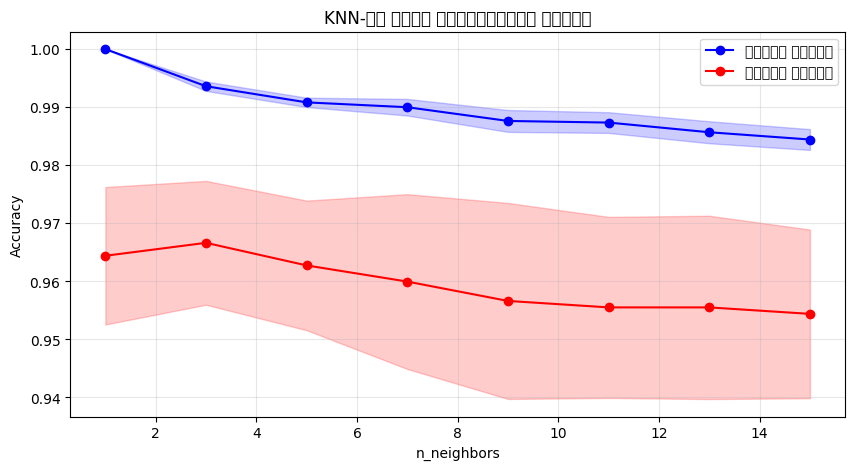

খেয়াল করো: n_neighbors=1 এ ট্রেন স্কোর 1.0 কিন্তু টেস্ট কম—এটা ওভারফিটিং
n_neighbors বাড়ালে ট্রেন-টেস্ট উভয়ই স্থিতিশীল হয়


In [3]:
# KNN-এর জন্য validation_curve
param_range = [1, 3, 5, 7, 9, 11, 13, 15]

train_scores, test_scores = validation_curve(
    KNeighborsClassifier(), X, y,
    param_name='n_neighbors', param_range=param_range,
    cv=5, scoring='accuracy', n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 5))
plt.plot(param_range, train_mean, 'o-', color='blue', label='ট্রেন স্কোর')
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
plt.plot(param_range, test_mean, 'o-', color='red', label='টেস্ট স্কোর')
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.2, color='red')
plt.xlabel('n_neighbors')
plt.ylabel('Accuracy')
plt.title('KNN-এর জন্য ভ্যালিডেশন কার্ভ')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print('খেয়াল করো: n_neighbors=1 এ ট্রেন স্কোর 1.0 কিন্তু টেস্ট কম—এটা ওভারফিটিং')
print('n_neighbors বাড়ালে ট্রেন-টেস্ট উভয়ই স্থিতিশীল হয়')

### E. RandomizedSearchCV: বড় জায়গায় দক্ষ অনুসন্ধান

GridSearchCV প্রতিটি কম্বিনেশন চেক করে। কিন্তু প্যারামিটার অনেক থাকলে এটি খুব ধীর হয়ে যায়। যেমন ১০টি প্যারামিটার × প্রতিটির ৫টি মান = ১০^৫ = ১,০০,০০০ কম্বিনেশন!

RandomizedSearchCV এই সমস্যার সমাধান করে। এটি সব কম্বিনেশন না দেখে, এলোমেলোভাবে নির্দিষ্ট সংখ্যক কম্বিনেশন বেছে নিয়ে পরীক্ষা করে। আশ্চর্যের ব্যাপার হলো, এটি প্রায় সবসময় GridSearchCV-র কাছাকাছি ফল দেয়, কিন্তু অনেক কম সময়ে!

**কৌশল:** `n_iter` দিয়ে আমরা কতবার র্যান্ডম কম্বিনেশন ট্রাই করব সেটা নির্ধারণ করি। বড় প্যারামিটার স্পেসের জন্য `n_iter=100` বা তার বেশি নেওয়া ভালো।

In [4]:
# Random Forest-এর জন্য RandomizedSearchCV
param_dist = {
    'n_estimators': [10, 50, 100, 200, 500],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf = RandomForestClassifier(random_state=42)
random_search = RandomizedSearchCV(
    rf, param_dist, n_iter=30, cv=5,
    scoring='accuracy', random_state=42, n_jobs=-1, verbose=1
)
random_search.fit(X, y)
print('\nRandomizedSearchCV সেরা প্যারামিটার:')
for param, value in random_search.best_params_.items():
    print(f'  {param}: {value}')
print(f'\nসেরা স্কোর: {random_search.best_score_:.4f}')
print(f'মোট {len(random_search.cv_results_["params"])} টি কম্বিনেশন ট্রাই করেছে (পরিকল্পিত ছিল 5×5×3×3×3 = 675)')

Fitting 5 folds for each of 30 candidates, totalling 150 fits



RandomizedSearchCV সেরা প্যারামিটার:
  n_estimators: 50
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: sqrt
  max_depth: None

সেরা স্কোর: 0.9399
মোট 30 টি কম্বিনেশন ট্রাই করেছে (পরিকল্পিত ছিল 5×5×3×3×3 = 675)


### F. গ্রিড সার্চ বনাম র্যান্ডমাইজড সার্চ

| দিক | GridSearchCV | RandomizedSearchCV |
|-----|-------------|-------------------|
| পদ্ধতি | সব কম্বিনেশন চেক করে | এলোমেলো কিছু কম্বিনেশন চেক করে |
| সময় | বেশি | কম |
| নির্ভুলতা | ১০০% (দেওয়া গ্রিডের মধ্যে) | প্রায় কাছাকাছি |
| কখন ব্যবহার করব | কম প্যারামিটার, ছোট গ্রিড | অনেক প্যারামিটার, বড় গ্রিড |
| প্যারামিটার | param_grid | param_distributions + n_iter |

### G. SVM-এর জন্য GridSearchCV (আরেকটি উদাহরণ)

এখন আমরা SVM (Support Vector Machine) ক্লাসিফায়ারের জন্য GridSearchCV ব্যবহার করব। SVM-এর C এবং gamma প্যারামিটার টিউন করা জরুরি।

SVM GridSearchCV ফলাফল:
  সেরা C: 10
  সেরা gamma: 0.001
  সেরা স্কোর: 0.9219


C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2474 (\N{BENGALI LETTER PA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2509 (\N{BENGALI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2479 (\N{BENGALI LETTER YA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserW

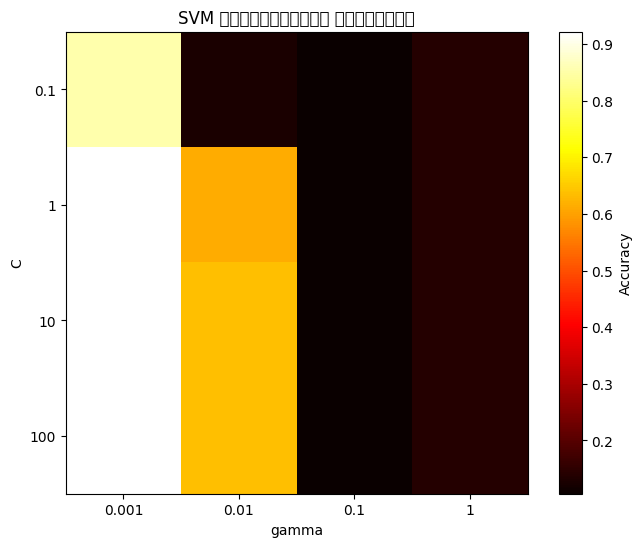

In [5]:
# SVM-এর জন্য ছোট GridSearch
X_small, y_small = X[:500], y[:500]  # সময় বাঁচাতে ছোট ডেটা

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}

svm = SVC()
grid_svm = GridSearchCV(svm, param_grid_svm, cv=3, scoring='accuracy', n_jobs=-1)
grid_svm.fit(X_small, y_small)
print('SVM GridSearchCV ফলাফল:')
print(f'  সেরা C: {grid_svm.best_params_["C"]}')
print(f'  সেরা gamma: {grid_svm.best_params_["gamma"]}')
print(f'  সেরা স্কোর: {grid_svm.best_score_:.4f}')

# হিটম্যাপ দেখি
results = grid_svm.cv_results_['mean_test_score'].reshape(4, 4)
plt.figure(figsize=(8, 6))
plt.imshow(results, cmap='hot', interpolation='nearest')
plt.colorbar(label='Accuracy')
plt.xticks(range(4), [0.001, 0.01, 0.1, 1])
plt.yticks(range(4), [0.1, 1, 10, 100])
plt.xlabel('gamma')
plt.ylabel('C')
plt.title('SVM প্যারামিটার হিটম্যাপ')
plt.show()

### H. গুরুত্বপূর্ণ টিপস

**১. প্যারামিটার রেঞ্জ ঠিক করা:** খুব ছোট রেঞ্জ দিলে সেরাটা খুঁজে নাও পেতে। খুব বড় দিলে সময় বেশি লাগবে। দুই ধাপে কাজ করা ভালো—প্রথমে বড় রেঞ্জ, তারপর ভালো জায়গায় সূক্ষ্ম রেঞ্জ।

**২. স্কোরিং মেট্রিক:** শুধু accuracy নয়, অন্য মেট্রিকও ব্যবহার করতে পারো। ইমব্যালেন্সড ডেটার জন্য `scoring='f1'` ভালো।

**৩. ওভারফিটিং চেক:** গ্রিড সার্চের সেরা প্যারামিটার সবসময়ই টেস্ট সেটে ভালো করবে না। আলাদা টেস্ট সেটে চেক করা জরুরি।

**৪. n_jobs=-1:** সব কোর ব্যবহার করে প্যারালাল প্রসেসিং—এটা অনেক সময় বাঁচায়।

### I. তুমি কি বুঝতে পেরেছ?

**প্রশ্ন ১:** GridSearchCV এবং RandomizedSearchCV-র মধ্যে পার্থক্য কী?

**প্রশ্ন ২:** ভ্যালিডেশন কার্ভ কী দেখায়?

**প্রশ্ন ৩:** অনেক প্যারামিটার থাকলে কেন RandomizedSearchCV বেশি কার্যকর?

**প্রশ্ন ৪:** গ্রিড সার্চের পরে কি আলাদা টেস্ট সেটে মডেল চেক করা উচিত? কেন?

### J. সারসংক্ষেপ

আজ আমরা শিখলাম:
✅ GridSearchCV সব প্যারামিটার কম্বিনেশন পদ্ধতিগতভাবে চেক করে
✅ RandomizedSearchCV এলোমেলোভাবে কিছু কম্বিনেশন চেক করে—দক্ষ ও কার্যকর
✅ validation_curve একটি প্যারামিটারের প্রভাব বুঝতে সাহায্য করে
✅ হাইপারপ্যারামিটার টিউনিং মডেলের পারফরম্যান্স ব্যাপকভাবে উন্নত করতে পারে
✅ ক্রস-ভ্যালিডেশনসহ GridSearch ব্যবহার করলে ফলাফল নির্ভরযোগ্য হয়

পরবর্তী পাঠে আমরা ইভালুয়েশন মেট্রিক্স নিয়ে শিখব—শুধু Accuracy নয়, আরও অনেক কিছু!